**LunarLander**: in acest mediu, se controleaza o nava spatiala care trebuie sa aterizeze pe o platforma.

*   sa aterizeze intre cele doua stegulete
*   cu viteza mica
*   cu unghi corect (aproape vertical)
*   fara sa te lovesti de sol

**Lumea:**

*   gravitatie (te trage in jos)
*   combustibil limitat
*   4 motoare: stanga, dreapta, motor principal (in sus), nimic (fara actiune)

Agentul primește un vector de 8 elemente:

*  pozitie X, Y
*  viteza X, Y
*  unghi (inclinare)
*  viteza unghiulara
*  contact picior stang/drept (bool)








In [1]:
!apt-get update -y
!apt-get install -y swig

!pip install -q "gymnasium[box2d]==0.29.1"
!pip install -q box2d-py==2.3.5
!pip install -q torch numpy matplotlib

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 2s (1,953 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
swig is already the newest version (4.0.2-1ubuntu1

In [3]:
import gymnasium as gym

env = gym.make("LunarLander-v2")
state, _ = env.reset()

print("Environment OK ✔")
print("State shape:", state.shape)
print("Action space:", env.action_space.n)

Environment OK ✔
State shape: (8,)
Action space: 4


In [5]:
import gymnasium as gym
import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim

# -------------------
# ENV
# -------------------
env = gym.make("LunarLander-v2")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------
# Hyperparams
# -------------------
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 64
MEMORY_SIZE = 50000
EPISODES = 700

EPS = 1.0
EPS_MIN = 0.05
EPS_DECAY = 0.995
TARGET_UPDATE = 10

# -------------------
# Replay buffer
# -------------------
class ReplayBuffer:
    def __init__(self, size):
        self.buffer = deque(maxlen=size)

    def push(self, s,a,r,s2,d):
        self.buffer.append((s,a,r,s2,d))

    def sample(self, batch):
        batch = random.sample(self.buffer, batch)
        s,a,r,s2,d = map(np.array, zip(*batch))
        return s,a,r,s2,d

    def __len__(self):
        return len(self.buffer)

memory = ReplayBuffer(MEMORY_SIZE)

# -------------------
# Network
# -------------------
class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self,x):
        return self.net(x)

policy = DQN().to(device)
target = DQN().to(device)
target.load_state_dict(policy.state_dict())

optimizer = optim.Adam(policy.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# -------------------
# Helpers
# -------------------
def act(state):
    global EPS
    if random.random() < EPS:
        return env.action_space.sample()

    state = torch.FloatTensor(state).unsqueeze(0).to(device)
    with torch.no_grad():
        return policy(state).argmax().item()

def train():
    if len(memory) < BATCH_SIZE:
        return

    s,a,r,s2,d = memory.sample(BATCH_SIZE)

    s = torch.FloatTensor(s).to(device)
    a = torch.LongTensor(a).to(device)
    r = torch.FloatTensor(r).to(device)
    s2 = torch.FloatTensor(s2).to(device)
    d = torch.FloatTensor(d).to(device)

    q = policy(s).gather(1,a.unsqueeze(1)).squeeze()

    with torch.no_grad():
        q_next = target(s2).max(1)[0]
        y = r + GAMMA * q_next * (1-d)

    loss = loss_fn(q, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# -------------------
# Training loop
# -------------------
rewards = []

for ep in range(EPISODES):
    state, _ = env.reset()
    done = False
    total = 0

    while not done:
        action = act(state)
        next_state, reward, term, trunc, _ = env.step(action)
        done = term or trunc

        memory.push(state, action, reward, next_state, done)

        state = next_state
        total += reward

        train()

    EPS = max(EPS_MIN, EPS * EPS_DECAY)
    rewards.append(total)

    if ep % TARGET_UPDATE == 0:
        target.load_state_dict(policy.state_dict())

    if ep % 10 == 0:
        print(f"Episode {ep} | reward: {total:.2f} | EPS: {EPS:.3f}")

Episode 0 | reward: -205.80 | EPS: 0.995
Episode 10 | reward: -85.47 | EPS: 0.946
Episode 20 | reward: -108.33 | EPS: 0.900
Episode 30 | reward: -245.62 | EPS: 0.856
Episode 40 | reward: -59.48 | EPS: 0.814
Episode 50 | reward: -45.30 | EPS: 0.774
Episode 60 | reward: -92.43 | EPS: 0.737
Episode 70 | reward: -71.76 | EPS: 0.701
Episode 80 | reward: -42.56 | EPS: 0.666
Episode 90 | reward: 22.86 | EPS: 0.634
Episode 100 | reward: 1.99 | EPS: 0.603
Episode 110 | reward: -61.29 | EPS: 0.573
Episode 120 | reward: -47.95 | EPS: 0.545
Episode 130 | reward: -30.44 | EPS: 0.519
Episode 140 | reward: -49.11 | EPS: 0.493
Episode 150 | reward: -53.80 | EPS: 0.469
Episode 160 | reward: 20.91 | EPS: 0.446
Episode 170 | reward: -30.67 | EPS: 0.424
Episode 180 | reward: -276.73 | EPS: 0.404
Episode 190 | reward: -60.55 | EPS: 0.384
Episode 200 | reward: -246.09 | EPS: 0.365
Episode 210 | reward: -82.77 | EPS: 0.347
Episode 220 | reward: -104.45 | EPS: 0.330
Episode 230 | reward: -31.81 | EPS: 0.314
E

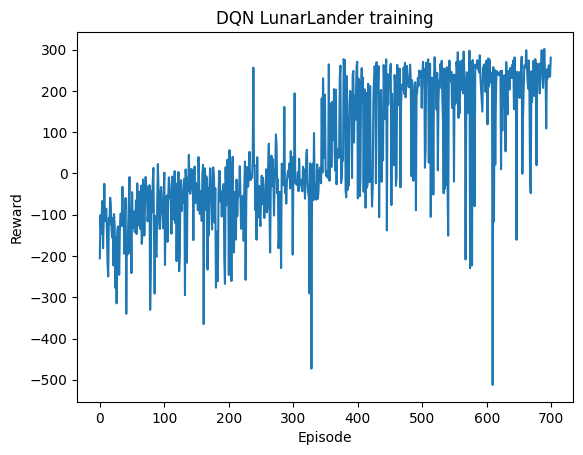

In [6]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.title("DQN LunarLander training")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()